# Anonymization Techniques: Applying Anonymization and Pseudonymization Methods

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply anonymization techniques
- Apply pseudonymization methods
- Protect personal data
- Understand k-anonymity
- Implement privacy-preserving methods

## 🔗 Where this fits

**Builds on:** Course 05 (AIAT 115) — Unit 2, lesson 02 "Missing Values & Duplicates" — the record-matching skill that finds the same person twice is the skill that re-identifies them.

---

This notebook covers practical activities from **Course 06, Unit 3**:
- Anonymization Techniques: Applying anonymization and pseudonymization methods

---

## Introduction

**Anonymization and pseudonymization** protect personal data by removing or replacing identifying information, enabling data use while preserving privacy.


## 📌 The case: Netflix published 100 million ratings and was told whose they were

In **2006** Netflix launched the Netflix Prize: a $1M open competition, and to run it the
company released the movie ratings of **about 500,000 subscribers**. Names and account
identifiers were stripped. What remained was, in Netflix's description, anonymous.

**Narayanan & Shmatikov, *Robust De-anonymization of Large Sparse Datasets* (2008)**, showed
that an adversary "who knows only a little bit about an individual subscriber can easily
identify this subscriber's record in the dataset". They cross-referenced the release against
public **IMDb** reviews and recovered the Netflix records of identifiable users — "uncovering
their apparent political preferences and other potentially sensitive information". Netflix
cancelled the planned sequel competition in 2010 after a lawsuit and regulatory pressure.

The mechanism is the one this notebook measures. Nobody was identified by a name; people were
identified because their **combination of ordinary attributes was unique**. A few obscure
films you rated is a fingerprint. So is sex + class + port + exact age.

**The WHY.** "We removed the names" is the most common false anonymisation claim in industry,
and the only way to refuse it is with a number. **k-anonymity** is that number: a table is
*k*-anonymous when every combination of quasi-identifiers appears in at least *k* rows, so
k = 1 means somebody is alone and therefore singled out. You are about to measure *k* on 891
real passengers, raise it by generalising, suppress what is still too rare — and then count
who you had to remove to get there.

---


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- The **real Titanic passenger manifest** (`load("titanic")`,
  891 real people). It has real direct identifiers (Name, Ticket, Cabin) and real
  quasi-identifiers (Sex, Pclass, Embarked, Age) - including 177 genuinely missing
  ages, which anonymization has to cope with.
- `pandas` and `hashlib`.

**Outputs:** What you'll see when you run the cells

- Pseudonymized records (real names replaced by salted-hash tokens).
- The **measured** k-anonymity of the real table, before and after generalization.
- The cost of reaching a target k: how many real passengers must be suppressed,
  and which people they turn out to be.

---


In [1]:
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # load("titanic"), load("creditcard_fraud"), ...
# -------------------------------------------------------------------------------------
print("Data loader ready - datasets are loaded by NAME, never by file path.")


Data loader ready - datasets are loaded by NAME, never by file path.


In [2]:
# Concept map: the two ways to de-identify data and the techniques behind them.
# Why first: the hands-on cell below applies these terms - read them here once.

import pandas as pd
import numpy as np
import hashlib

print("✅ Libraries imported!")
print("\nAnonymization and Pseudonymization")
print("=" * 60)

# Anonymization is IRREVERSIBLE: once done properly, no one can link the data
# back to a person - which is why GDPR no longer applies to truly anonymous data.
print("\nAnonymization:")
print("  - Remove identifiers")
print("  - Generalize data")
print("  - Suppress values")
print("  - k-anonymity")

# Pseudonymization is REVERSIBLE by whoever holds the mapping/salt -
# the data is still personal data under GDPR.
print("\nPseudonymization:")
print("  - Replace identifiers")
print("  - Reversible mapping")
print("  - Hash functions")
print("  - Tokenization")

print("\nTechniques:")
print("  - Generalization")
print("  - Suppression")
print("  - Perturbation")
print("  - Data masking")

print("\n✅ Anonymization concepts understood!")

✅ Libraries imported!

Anonymization and Pseudonymization

Anonymization:
  - Remove identifiers
  - Generalize data
  - Suppress values
  - k-anonymity

Pseudonymization:
  - Replace identifiers
  - Reversible mapping
  - Hash functions
  - Tokenization

Techniques:
  - Generalization
  - Suppression
  - Perturbation
  - Data masking

✅ Anonymization concepts understood!


## Hands-on: Anonymization, Pseudonymization, and k-Anonymity

**k-anonymity**: a table is *k*-anonymous if every combination of **quasi-identifiers**
(attributes that identify someone when combined - here sex, class, port, age) appears in at
least *k* rows. If a combination is unique (k = 1), that person can be singled out.

We measure k on the **real** 891-passenger manifest, raise it by **generalizing** the
quasi-identifiers, then **suppress** the rows that are still too rare - and finally count
what that protection cost us. Exercise 2 (Task 1) asks you to implement the same recipe.


In [3]:
# WHY on real data: k-anonymity is a property of a real population. Invented
# tables give whatever k you designed into them; a real manifest tells you how
# exposed real people actually are - and what protecting them costs.

# Practice: pseudonymize, then measure and improve k-anonymity

df = load("titanic")  # Load: 891 real passengers, by name not by path
print(f"Real Titanic manifest: {len(df)} passengers, {df.shape[1]} columns")
print(f"Direct identifiers present: Name, Ticket, Cabin")
print(f"Genuinely missing values: Age {int(df['Age'].isna().sum())}, "
      f"Cabin {int(df['Cabin'].isna().sum())}, Embarked {int(df['Embarked'].isna().sum())}")
print("\nFirst rows as they come out of the file:")
print(df[['Name', 'Sex', 'Age', 'Pclass', 'Embarked', 'Ticket']].head(5).to_string(index=False))

# --- Pseudonymize the direct identifiers ---
# A salted hash gives every person a stable token: the same name always maps to
# the same token, so records stay linkable without showing who they belong to.
SALT = 'unit3-demo'  # In production: a secret kept apart from the data
def token(value, salt=SALT):
    return hashlib.sha256((salt + str(value)).encode()).hexdigest()[:10]

df_pseudo = df.copy()
df_pseudo['person_id'] = df_pseudo['Name'].apply(token)  # Tokenize: real name -> pseudonym
df_pseudo = df_pseudo.drop(columns=['Name', 'Ticket', 'Cabin', 'PassengerId'])
df_pseudo = df_pseudo[['person_id', 'Sex', 'Age', 'Pclass', 'Embarked', 'Survived']]
print("\nAfter pseudonymization (name -> salted hash, ticket and cabin dropped):")
print(df_pseudo.head(5).to_string(index=False))

# --- Measure k-anonymity over the quasi-identifiers ---
def k_anonymity(table, quasi_identifiers):
    """Smallest group size over the quasi-identifier combinations that occur.
    dropna=False keeps the missing-age rows as their own group - they are real
    people too, and ignoring them would flatter the result."""
    return int(table.groupby(quasi_identifiers, observed=True, dropna=False).size().min())

QI = ['Sex', 'Pclass', 'Embarked', 'Age']
k_before = k_anonymity(df_pseudo, QI)
sizes_before = df_pseudo.groupby(QI, observed=True, dropna=False).size()
print(f"\nk-anonymity over {QI}: k = {k_before}")
print(f"{int((sizes_before == 1).sum())} of the {len(sizes_before)} combinations that occur "
      f"are held by exactly ONE passenger.")
print("k = 1 means those people have a UNIQUE quasi-identifier combination - an")
print("attacker who knows their sex, class, port and age can single them out,")
print("even though we deleted every name.")

# --- Step A: Generalize quasi-identifiers (coarser values -> bigger groups) ---
AGE_BINS, AGE_LABELS = [0, 18, 30, 45, 120], ['<=18', '19-30', '31-45', '46+']
df_gen = df_pseudo.copy()
df_gen['Age'] = pd.cut(df_gen['Age'], bins=AGE_BINS, labels=AGE_LABELS)  # Generalize: exact age -> band
print("\nAfter generalization (exact age -> 4 age bands):")
print(df_gen.head(5).to_string(index=False))
k_gen = k_anonymity(df_gen, QI)
sizes_gen = df_gen.groupby(QI, observed=True, dropna=False).size()
print(f"k-anonymity after generalization: k = {k_gen}  (was {k_before})")
print(f"Combinations held by a single passenger: "
      f"{int((sizes_gen == 1).sum())} (was {int((sizes_before == 1).sum())})")
print("-> Generalization removed most of the exposure, but k is still 1: a few")
print("   real passengers remain unique even inside broad age bands.")

# --- Step B: Suppress rows still in groups smaller than the target k ---
TARGET_K = 5  # Common regulatory rule of thumb for released microdata
group_sizes = df_gen.groupby(QI, observed=True, dropna=False)['person_id'].transform('size')
df_k = df_gen[group_sizes >= TARGET_K]  # Keep: rows whose group is big enough
suppressed = df_gen[group_sizes < TARGET_K]  # Drop: the still-identifiable rows
k_after = k_anonymity(df_k, QI)
print(f"\nSuppressing every row whose group is smaller than k={TARGET_K}:")
print(f"  released: {len(df_k)} passengers    suppressed: {len(suppressed)} "
      f"({len(suppressed)/len(df_gen):.1%} of the manifest)")
print(f"  final k-anonymity: k = {k_after} (target was {TARGET_K})")
print("Generalize first, then suppress the stubborn outliers - the standard recipe.")

# --- What did the protection cost? Measure it, do not assume it ---
# The suppressed rows are the RAREST people, so releasing only the survivors
# changes the picture the data gives - which is the privacy/utility trade-off.
print("\nCOST OF PROTECTION (real numbers, not a rule of thumb):")
print(f"  survival rate   before {df_gen['Survived'].mean():.1%}  ->  after {df_k['Survived'].mean():.1%}")
print(f"  share female    before {(df_gen['Sex'] == 'female').mean():.1%}  ->  after {(df_k['Sex'] == 'female').mean():.1%}")
print("\nRead the suppressed group before you accept the trade-off:")
print(suppressed.groupby(['Sex', 'Pclass'], observed=True).size().to_string())
# Say it with a number: are the suppressed people a random slice of the ship?
share_female_all = (df_gen['Sex'] == 'female').mean()
share_female_supp = (suppressed['Sex'] == 'female').mean()
print(f"\nWomen are {share_female_all:.1%} of the manifest but "
      f"{share_female_supp:.1%} of the {len(suppressed)} suppressed passengers.")

print("\n-> Suppression removes the people with rare attribute combinations, and")
print("   rare combinations are exactly where minorities live. Privacy protection")
print("   quietly reshapes who is represented in the released data - Unit 2's")
print("   fairness problem, created by Unit 3's privacy fix. Both matter; you have")
print("   to decide the balance openly, and document it.")
print("\n\u2705 You just did what Exercise 2 Task 1 asks: check k, generalize, re-check.")


titanic: full file, 891 rows.
Real Titanic manifest: 891 passengers, 12 columns
Direct identifiers present: Name, Ticket, Cabin
Genuinely missing values: Age 177, Cabin 687, Embarked 2

First rows as they come out of the file:
                                               Name    Sex  Age  Pclass Embarked           Ticket
                            Braund, Mr. Owen Harris   male 22.0       3        S        A/5 21171
Cumings, Mrs. John Bradley (Florence Briggs Thayer) female 38.0       1        C         PC 17599
                             Heikkinen, Miss. Laina female 26.0       3        S STON/O2. 3101282
       Futrelle, Mrs. Jacques Heath (Lily May Peel) female 35.0       1        S           113803
                           Allen, Mr. William Henry   male 35.0       3        S           373450

After pseudonymization (name -> salted hash, ticket and cabin dropped):
 person_id    Sex  Age  Pclass Embarked  Survived
088be50159   male 22.0       3        S         0
4d0f50b974 f

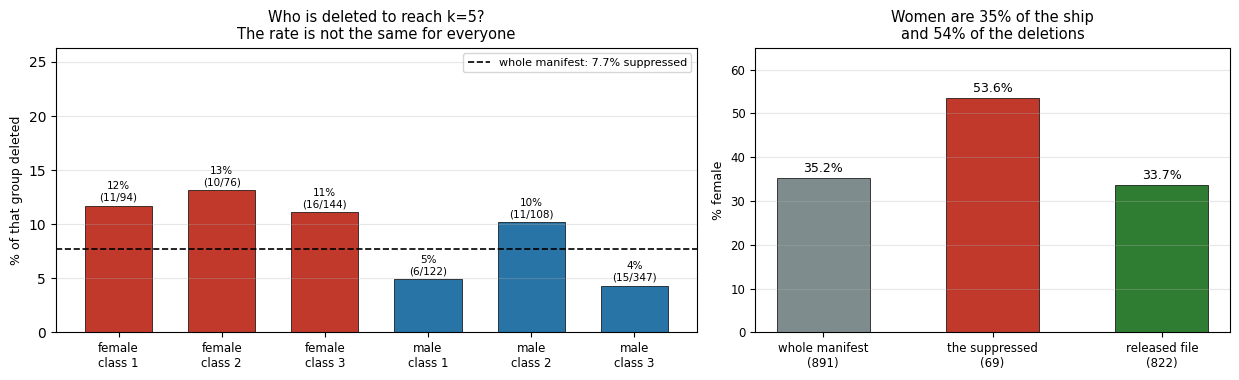

In [4]:
# WHY a picture here: the printed table above says women are 35% of the manifest
# and 54% of the suppressed rows. That sentence is the whole ethical content of
# k-anonymity, and it is buried in a wall of text. Drawn, it is unarguable.
# (Notebook 01 draws the other half of the story - how the risk arises.)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.9), gridspec_kw={'width_ratios': [1.35, 1]})

# --- Left: what share of each Sex x Class group was deleted to reach k=5 ---
totals = df_gen.groupby(['Sex', 'Pclass'], observed=True).size()
suppressed_n = (suppressed.groupby(['Sex', 'Pclass'], observed=True).size()
                .reindex(totals.index, fill_value=0))
rate = suppressed_n / totals * 100          # % of that group that disappears
overall_rate = len(suppressed) / len(df_gen) * 100

ax = axes[0]
xs = np.arange(len(totals))
labels = [f'{sex}\nclass {cls}' for sex, cls in totals.index]
colours = ['#c0392b' if sex == 'female' else '#2874a6' for sex, _ in totals.index]
bars = ax.bar(xs, rate.values, color=colours, width=0.65, edgecolor='black', linewidth=0.5)
ax.bar_label(bars, labels=[f'{r:.0f}%\n({n}/{t})' for r, n, t
                           in zip(rate.values, suppressed_n.values, totals.values)],
             fontsize=7.5, padding=2)
ax.axhline(overall_rate, color='black', ls='--', lw=1.2,
           label=f'whole manifest: {overall_rate:.1f}% suppressed')
ax.set_xticks(xs); ax.set_xticklabels(labels, fontsize=8.5)
ax.set_ylabel('% of that group deleted', fontsize=9)
ax.set_ylim(0, max(rate.values) * 2.0)
ax.set_title(f'Who is deleted to reach k={TARGET_K}?\nThe rate is not the same for everyone',
             fontsize=10.5)
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

# --- Right: the same finding as one composition comparison ---
ax = axes[1]
shares = [(df_gen['Sex'] == 'female').mean() * 100,
          (suppressed['Sex'] == 'female').mean() * 100,
          (df_k['Sex'] == 'female').mean() * 100]
names = [f'whole manifest\n({len(df_gen)})', f'the suppressed\n({len(suppressed)})',
         f'released file\n({len(df_k)})']
bars = ax.bar(names, shares, color=['#7f8c8d', '#c0392b', '#2e7d32'], width=0.55,
              edgecolor='black', linewidth=0.5)
ax.bar_label(bars, fmt='%.1f%%', fontsize=9, padding=2)
ax.set_ylabel('% female', fontsize=9); ax.set_ylim(0, 65)
ax.set_title(f'Women are {shares[0]:.0f}% of the ship\nand {shares[1]:.0f}% of the deletions',
             fontsize=10.5)
ax.tick_params(labelsize=8.5); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


**Read the picture.** Both panels describe the **69 passengers deleted** to raise the table
from k = 1 to k = 5. Nothing here is about who *survived*; it is about who survives the
*anonymisation*.

*Left* — the share of each sex-and-class group that was deleted. The dashed line is the
overall rate, **7.7 %**. Every one of the three female bars sits **above** it (11 %, 13 %,
11 %); two of the three male bars sit well **below** it (4.9 % and 4.3 %). Women in second
class lose one passenger in eight; men in third class lose one in twenty-three.

*Right* — the same fact stated once. Women are **35.2 %** of the manifest, **53.6 %** of the
deleted rows, and therefore **33.7 %** of the file that actually gets published.

**What it proves:** suppression is not a neutral technical step. It removes the people with
rare attribute combinations, and rare is where minorities live — so a k-anonymous release is
one in which unusual people have been quietly thinned out. Every analysis run on the released
file inherits that shift. This is Unit 2's fairness problem, manufactured by Unit 3's privacy
fix, and it is the reason a data-sharing note must report *how many rows were suppressed and
which*, not only the value of k.


## 💬 Discuss

Notebook 01 measured, on this same real file with the names already deleted: **224 people
(25.1 %) unique** on `[Sex, Pclass, Embarked, exact Age]`, falling to **11 people (1.2 %)**
once age is banded. This notebook measures the rest of the recipe — what *k* you reach, and
what suppression costs.

1. **Choose k, and say who pays.** Raising *k* means widening bands and deleting rows. The
   rows you delete are, by construction, **the most unusual people in the file** — the
   oldest passenger, the rarest class-and-port combination. So a k-anonymous release is one
   in which unusual people have been erased. If this were a medical registry, whose disease
   just disappeared from the research literature? Pick your *k* and defend the deletion.
2. **Anonymous, or pseudonymous?** Properly anonymised data leaves GDPR's scope entirely;
   pseudonymised data does not, so it keeps every obligation — and every capability. Give one
   concrete scenario from your own field where the *right* answer is pseudonymisation
   precisely **because** it is reversible, and say who should hold the salt.
3. **Can anyone honestly promise anonymity?** The Netflix record was ruined by an auxiliary
   dataset (IMDb) that the publisher had never heard of, and cannot enumerate. If the risk
   depends on data that does not exist yet, is "this dataset is anonymised" a claim anyone
   can responsibly make? What would you write instead on a data-sharing agreement — and
   would your legal department accept it?


---

## ➡️ You've Finished Unit 3

With notebooks 06-07 done, you have now *practiced* the two core protection techniques
from Notebook 01 (encryption; anonymization/pseudonymization) and measured k-anonymity.

**Next**: the unit exercises (`exercises/exercise_01.ipynb`, `exercises/exercise_02.ipynb`),
then **Unit 4: Transparency and Accountability** (`unit4-transparency-accountability/`).

## ⚠️ Where this breaks

- **k-anonymity says nothing about what an attacker learns.** If every person in a *k*-sized
  bucket shares the same sensitive value — all five died, all five have the same diagnosis —
  then knowing someone's bucket reveals their outcome without identifying anyone. That is
  **attribute disclosure**, and it is why *l*-diversity (Machanavajjhala et al., 2007) and
  *t*-closeness exist. Reporting *k* alone is an incomplete safety claim.
- **You must choose the quasi-identifiers, and you will choose wrongly.** We picked sex,
  class, port and age. Fare, cabin letter and family size are also quasi-identifiers, and in
  a real file so are timestamps, device IDs and free-text notes. Every column you fail to
  classify as a quasi-identifier is a re-identification route you never measured.
- **The guarantee does not compose.** Two *k*-anonymous releases of overlapping populations
  can be joined to break both. k-anonymity is a property of **one table in isolation**, which
  is exactly the failure the Netflix Prize suffered. Differential privacy (Notebook 03) is the
  framework that tracks cumulative loss instead.
- **Auxiliary information is unbounded and grows over time.** A release that is safe today
  becomes unsafe when an unrelated dataset appears — as IMDb did. Anonymisation cannot be
  certified once and forgotten.
- **Suppression is not neutral.** The rows it removes are the unusual ones, so the protection
  itself introduces a systematic bias in whatever analysis follows. Report how many rows you
  suppressed and which, or the downstream researcher will draw conclusions about a population
  you quietly edited.

**The cheaper alternative:** for most internal analytics, **do not release a table at all**.
Answer queries against the data behind an access-controlled interface, log every query, and
release only the aggregates — with DP noise if the audience is public. The release you never
make cannot be re-identified.


## 🔭 State of the field (2026)

*Context, not examinable content — the official unit examines the techniques above, exactly as they are taught. This box says where they sit on the 2026 map.*

The case this notebook opens with has been re-run with 2026 tools, and it got worse: Ko *et al.*
(2026) put LLM-based agents on a Netflix-Prize-style re-identification task and report **79.2 %** of
identities reconstructed against **56.0 %** for a classical matching baseline, with agents linking
individuals even when never explicitly asked to. The auxiliary information that broke the Netflix
release was IMDb, which a publisher might at least have named; the auxiliary information now is
whatever an agent can reach, which nobody can enumerate in advance. The effect your right-hand panel
measures has also been audited as a general property rather than a quirk of this file — Arcolezi
*et al.* (2025) put k-anonymity, ℓ-diversity and t-closeness through a fairness audit and find group
fairness metrics degraded **by up to fourfold**, while similarity-based *individual* fairness appears
to improve, for the uncomfortable reason that generalisation makes everyone's input look more alike.

Which is precisely why *k* is still the number to learn and why the official plan examines it: it is
the only way to refuse "we removed the names, so it is anonymous" with evidence rather than opinion,
and the audit you ran is the one a data-sharing note must carry — **69 passengers suppressed to
reach k = 5**, women **35.2 %** of the manifest but **53.6 %** of the deleted rows. Report *k* alone
and you have made half a claim; report who the protection removed, and add that *k* is a floor
computed against the auxiliary data you happen to know about, and you have made an honest one.

**Read:** Arcolezi *et al.* (2025), <https://arxiv.org/abs/2505.07985> · Ko *et al.* (2026), <https://arxiv.org/abs/2603.18382> (references 5-6 below).

---

## 📚 References

1. Sweeney, L. (2002). *k-Anonymity: A Model for Protecting Privacy*. International Journal of Uncertainty, Fuzziness and Knowledge-Based Systems, 10(5).
2. Machanavajjhala, A., Kifer, D., Gehrke, J. & Venkitasubramaniam, M. (2007). *l-Diversity: Privacy Beyond k-Anonymity*. ACM Transactions on Knowledge Discovery from Data, 1(1).
3. Narayanan, A. & Shmatikov, V. (2007). *How To Break Anonymity of the Netflix Prize Dataset*. <https://arxiv.org/abs/cs/0610105>
4. European Parliament & Council (2016). *Regulation (EU) 2016/679 — General Data Protection Regulation (GDPR)*. <https://gdpr-info.eu/>
5. Arcolezi, H. H., Alishahi, M., Bendoukha, A.-A. & Kaaniche, N. (2025). *Fair Play for Individuals, Foul Play for Groups? Auditing Anonymization's Impact on ML Fairness*. arXiv:2505.07985. <https://arxiv.org/abs/2505.07985> (k-anonymity, l-diversity and t-closeness audited for their effect on group fairness)
6. Ko, M., Jeong, J., Thakur, S. S., Kim, G. & Jia, R. (2026). *From Weak Cues to Real Identities: Evaluating Inference-Driven De-Anonymization in LLM Agents*. arXiv:2603.18382. <https://arxiv.org/abs/2603.18382> (the Netflix Prize re-identification, re-run by LLM agents)
